# Sex Heterogeneity FDR Correction

In [35]:
import pandas as pd
import numpy as np
import numpy as np
from statsmodels.stats.multitest import multipletests
import seaborn as sns

In [5]:
afr_metai = pd.read_csv('Fin8-Supplemental_Table8_CMVD_AFR_MF_global_reserve_merged_meta_I.csv', sep = '\t')
afr_metai

,Unnamed: 0,CHR,BP,SNP,A1,A2,N,P,P(R),OR,OR(R),Q,I
0,0,1,66861,chr1:66861:C:T,T,C,2,0.5623,0.5710,1.0383,1.0383,0.3068,4.27
1,1,1,80346,chr1:80346:C:G,G,C,2,0.1543,0.1543,0.9187,0.9187,0.8280,0.00
2,2,1,457841,chr1:457841:A:C,C,A,2,0.5229,0.5618,0.9473,0.9448,0.2495,24.59
3,3,1,595259,chr1:595259:G:A,A,G,2,0.8311,0.8311,0.9848,0.9848,0.6296,0.00
4,4,1,634553,chr1:634553:G:A,A,G,2,0.4073,0.4073,1.0769,1.0769,0.7742,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7754071,7754071,22,50797551,chr22:50797551:G:A,A,G,2,0.3646,0.3646,0.9645,0.9645,0.5052,0.00
7754072,7754072,22,50798021,chr22:50798021:A:G,G,A,2,0.1927,0.1927,1.0599,1.0599,0.8030,0.00
7754073,7754073,22,50798635,chr22:50798635:T:C,C,T,2,0.3784,0.3784,1.0530,1.0530,0.7701,0.00
7754074,7754074,22,50799821,chr22:50799821:A:C,C,A,2,0.2433,0.4910,1.0471,1.0435,0.1183,59.01


In [51]:
# use Q or P 
qvals = afr_metai["Q"].values
pvals = afr_metai["P"].values

# BH FDR across ALL variants
afr_metai["FDR"] = multipletests(qvals, method="fdr_bh")[1]
afr_metai["FDR_P"] = multipletests(pvals, method="fdr_bh")[1]


# Variants passing nominal threshold
subset = afr_metai[afr_metai["Q"] < 5e-4]

print("Number with p < 5e-4:", subset.shape[0])
print("Mean FDR:", subset["FDR"].mean())
print("Median FDR:", subset["FDR"].median())
print("Max FDR:", subset["FDR"].max())

print("Mean I:", subset["I"].mean())
print("Median I:", subset["I"].median())
print("Max I:", subset["I"].max())


Number with p < 5e-4: 2721
Mean FDR: 0.816778935350452
Median FDR: 0.9784323028391168
Max FDR: 0.9999513253452104
Mean I: 92.89989342153629
Median I: 92.76
Max I: 96.02


In [49]:
subset = afr_metai[afr_metai["Q"] < 5e-6]

print("Number with p < 2e-6:", subset.shape[0])
print("Mean FDR:", subset["FDR"].mean())
print("Median FDR:", subset["FDR"].median())
print("Max FDR:", subset["FDR"].max())
print("Min FDR:", subset["FDR"].min())

print("Mean I:", subset["I"].mean())
print("Median I:", subset["I"].median())
print("Max I:", subset["I"].max())

Number with p < 2e-6: 316
Mean FDR: 0.0
Median FDR: 0.0
Max FDR: 0.0
Min FDR: 0.0
Mean I: 94.53838607594938
Median I: 94.505
Max I: 96.02


In [60]:
fdr_sig_afr = afr_metai[afr_metai['FDR'] < 0.05]
fdr_sig_afr

,Unnamed: 0,CHR,BP,SNP,A1,A2,N,P,P(R),OR,OR(R),Q,I,FDR,FDR_P
52872,52872,1,18316513,chr1:18316513:A:G,G,A,2,0.5365,0.7777,1.0196,1.0391,0.0,94.55,0.0,0.999931
52877,52877,1,18317083,chr1:18317083:G:A,A,G,2,0.5580,0.7780,1.0185,1.0390,0.0,94.52,0.0,0.999931
52883,52883,1,18318517,chr1:18318517:T:A,A,T,2,0.5618,0.7841,1.0183,1.0382,0.0,94.64,0.0,0.999931
52919,52919,1,18325749,chr1:18325749:G:A,A,G,2,0.2684,0.7588,0.9277,0.9171,0.0,94.20,0.0,0.999931
314214,314214,1,119244631,chr1:119244631:A:G,G,A,2,0.2488,0.9327,1.0767,1.0251,0.0,95.05,0.0,0.999931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7392265,7392265,20,8777041,chr20:8777041:A:G,G,A,2,0.7184,0.9183,1.0166,1.0194,0.0,94.06,0.0,0.999931
7392489,7392489,20,8818524,chr20:8818524:A:G,G,A,2,0.3127,0.9798,0.9474,0.9943,0.0,94.16,0.0,0.999931
7449395,7449395,20,32647980,chr20:32647980:C:A,A,C,2,0.6854,0.9018,0.9879,0.9836,0.0,94.98,0.0,0.999931
7449408,7449408,20,32652127,chr20:32652127:A:G,G,A,2,0.4714,0.8253,0.9790,0.9724,0.0,94.54,0.0,0.999931


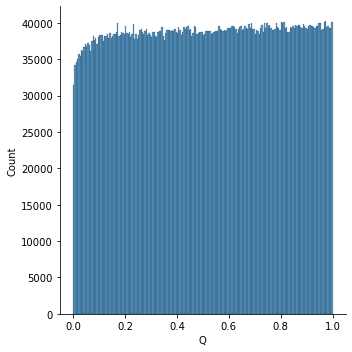

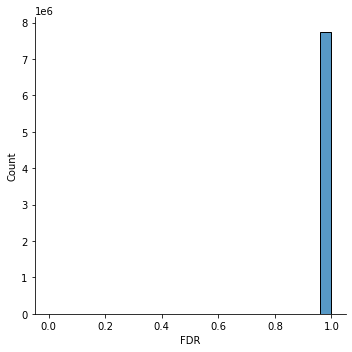

In [40]:
sns.displot(afr_metai['Q'])
sns.displot(afr_metai['FDR'])

In [36]:
eur_metai = pd.read_csv('Fin9-Supplemental_Table9_CMVD_EUR_MF_global_reserve_merged_meta_I.csv', sep = '\t')
# use Q or P depending on your analysis
pvals = eur_metai["Q"].values  

# BH FDR across ALL variants
eur_metai["FDR"] = multipletests(pvals, method="fdr_bh")[1]

# Variants passing nominal threshold
subset = eur_metai[eur_metai["Q"] < 5e-4]

print("Number with p < 5e-4:", subset.shape[0])
print("Mean FDR:", subset["FDR"].mean())
print("Median FDR:", subset["FDR"].median())
print("Max FDR:", subset["FDR"].max())

print("Mean I:", subset["I"].mean())
print("Median I:", subset["I"].median())
print("Max I:", subset["I"].max())


Number with p < 5e-4: 766
Mean FDR: 0.9477250700038694
Median FDR: 0.9999413273043616
Max FDR: 0.9999413273043616
Mean I: 92.5794255874673
Median I: 92.35
Max I: 94.89


In [58]:
fdr_sig_eur = eur_metai[eur_metai['FDR'] <= 0.05]
fdr_sig_eur

,Unnamed: 0,CHR,BP,SNP,A1,A2,N,P,P(R),OR,OR(R),Q,I,FDR
690036,690036,2,190439423,chr2:190439423:A:G,G,A,2,0.98150,0.7606,0.9993,1.0411,0.0,94.15,0.0
690041,690041,2,190441257,chr2:190441257:T:C,C,T,2,0.96470,0.7638,0.9987,1.0403,0.0,94.08,0.0
690043,690043,2,190442000,chr2:190442000:A:G,G,A,2,0.98020,0.7608,0.9993,1.0410,0.0,94.15,0.0
690050,690050,2,190446286,chr2:190446286:A:G,G,A,2,0.97310,0.7605,0.9990,1.0412,0.0,94.17,0.0
690061,690061,2,190452950,chr2:190452950:C:T,T,C,2,0.97110,0.7606,0.9989,1.0410,0.0,94.13,0.0
690075,690075,2,190460529,chr2:190460529:C:G,G,C,2,0.96790,0.7602,0.9988,1.0412,0.0,94.15,0.0
1208333,1208333,4,37694099,chr4:37694099:A:C,C,A,2,0.87420,0.8110,1.0069,1.0469,0.0,94.59,0.0
1481301,1481301,4,187938754,chr4:187938754:A:G,G,A,2,0.01053,0.4300,1.0945,1.1258,0.0,94.24,0.0
1898765,1898765,6,39179403,chr6:39179403:C:T,T,C,2,0.52740,0.9216,1.0213,0.9860,0.0,94.17,0.0
1898766,1898766,6,39180394,chr6:39180394:A:C,C,A,2,0.50660,0.9282,1.0224,0.9872,0.0,94.22,0.0


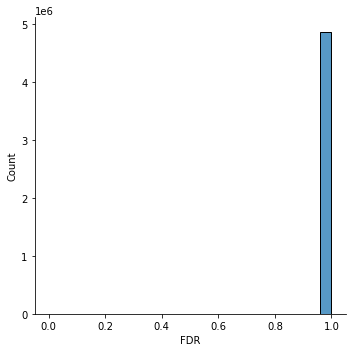

In [47]:
sns.displot(eur_metai['FDR'])

In [64]:
fdr_sig_afr_eur = pd.concat([fdr_sig_afr, fdr_sig_eur])
len(fdr_sig_afr_eur['SNP'].unique())

356